# 📊 Étape 1 — Analyse Exploratoire des Données (EDA)
**Projet :** Classification Customer Churn — Telco Dataset  
**Dataset :** 7 043 clients, 21 variables mixtes  

---
**Comment utiliser ce notebook :** `Kernel → Restart & Run All` pour tout exécuter d'un coup.

## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BLUE   = '#4C9BE8'
ORANGE = '#E8734C'
PALETTE = {'No': BLUE, 'Yes': ORANGE}

# Créer les dossiers nécessaires
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print('✅ Imports OK')
print('✅ Dossiers créés')

✅ Imports OK
✅ Dossiers créés


## 1. Chargement des données

In [2]:
df = pd.read_csv(r'C:\Users\FARAH\classification-churn-project\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 7,043 lignes × 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('=== Types de colonnes ===')
print(df.dtypes)

=== Types de colonnes ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


## 2. Qualité des données

> **`TotalCharges`** est stockée en `object`. 11 lignes contiennent un espace vide (clients avec `tenure=0`).  
> Correction : conversion en `float64` + imputation par `MonthlyCharges × tenure`.

In [4]:
# Détection
blank = df[df['TotalCharges'].str.strip() == '']
print(f'Valeurs TotalCharges vides : {len(blank)}')
print(blank[['customerID','tenure','MonthlyCharges','TotalCharges','Churn']])

# Correction
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'Non', 1: 'Oui'})

print(f'\nValeurs manquantes restantes : {df.isnull().sum().sum()}')
print('✅ TotalCharges corrigé')

Valeurs TotalCharges vides : 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

Valeurs manquantes restantes : 0
✅ TotalCharges corrigé


## 3. Variable cible — Déséquilibre des classes

Déséquilibre modéré : ~26.5% churners (ratio 2.77:1) → justifie **SMOTE-NC** à l'étape 4.

In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('=== Distribution Churn ===')
print(pd.DataFrame({'Count': churn_counts, 'Pourcentage (%)': churn_pct.round(2)}))
print(f'\nRatio déséquilibre : {churn_counts["No"]/churn_counts["Yes"]:.2f}:1')

=== Distribution Churn ===
       Count  Pourcentage (%)
Churn                        
No      5174            73.46
Yes     1869            26.54

Ratio déséquilibre : 2.77:1


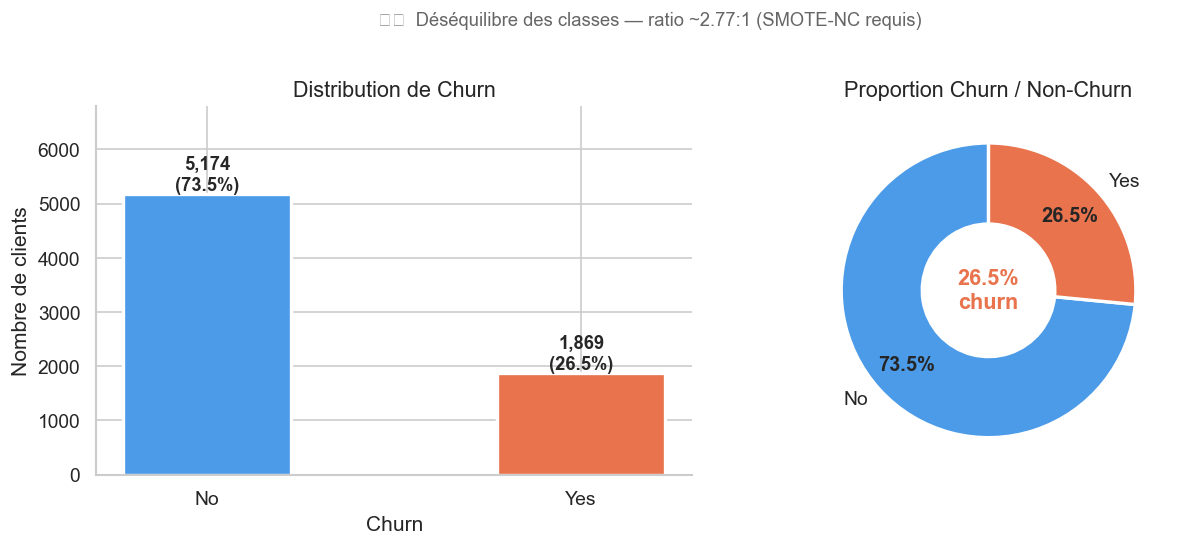

✅ fig1 sauvegardée


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Barplot
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[BLUE, ORANGE], width=0.45, edgecolor='white', linewidth=2)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution de Churn', fontsize=13)
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Nombre de clients')
axes[0].set_ylim(0, 6800)

# Donut
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
    colors=[BLUE, ORANGE], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2), pctdistance=0.75)
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(12)
axes[1].text(0, 0, f'{churn_pct["Yes"]:.1f}%\nchurn', ha='center', va='center',
             fontsize=13, fontweight='bold', color=ORANGE)
axes[1].set_title('Proportion Churn / Non-Churn', fontsize=13)

plt.suptitle('⚠️  Déséquilibre des classes — ratio ~2.77:1 (SMOTE-NC requis)',
             fontsize=11, color='#666', y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig1_churn_distribution.png', bbox_inches='tight')
plt.show()
print('✅ fig1 sauvegardée')

## 4. Variables quantitatives — Distributions & boxplots

| Variable | Médiane No Churn | Médiane Churn | Observation |
|---|---|---|---|
| `tenure` | 38 mois | **10 mois** | Churners partent tôt |
| `MonthlyCharges` | 64.4 $ | **79.7 $** | Churners paient plus cher |
| `TotalCharges` | 1679.5 $ | 703.5 $ | Corrélé à la tenure |

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('=== Statistiques par groupe Churn ===')
df.groupby('Churn')[num_cols].agg(['mean','median','std']).round(2)

=== Statistiques par groupe Churn ===


tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

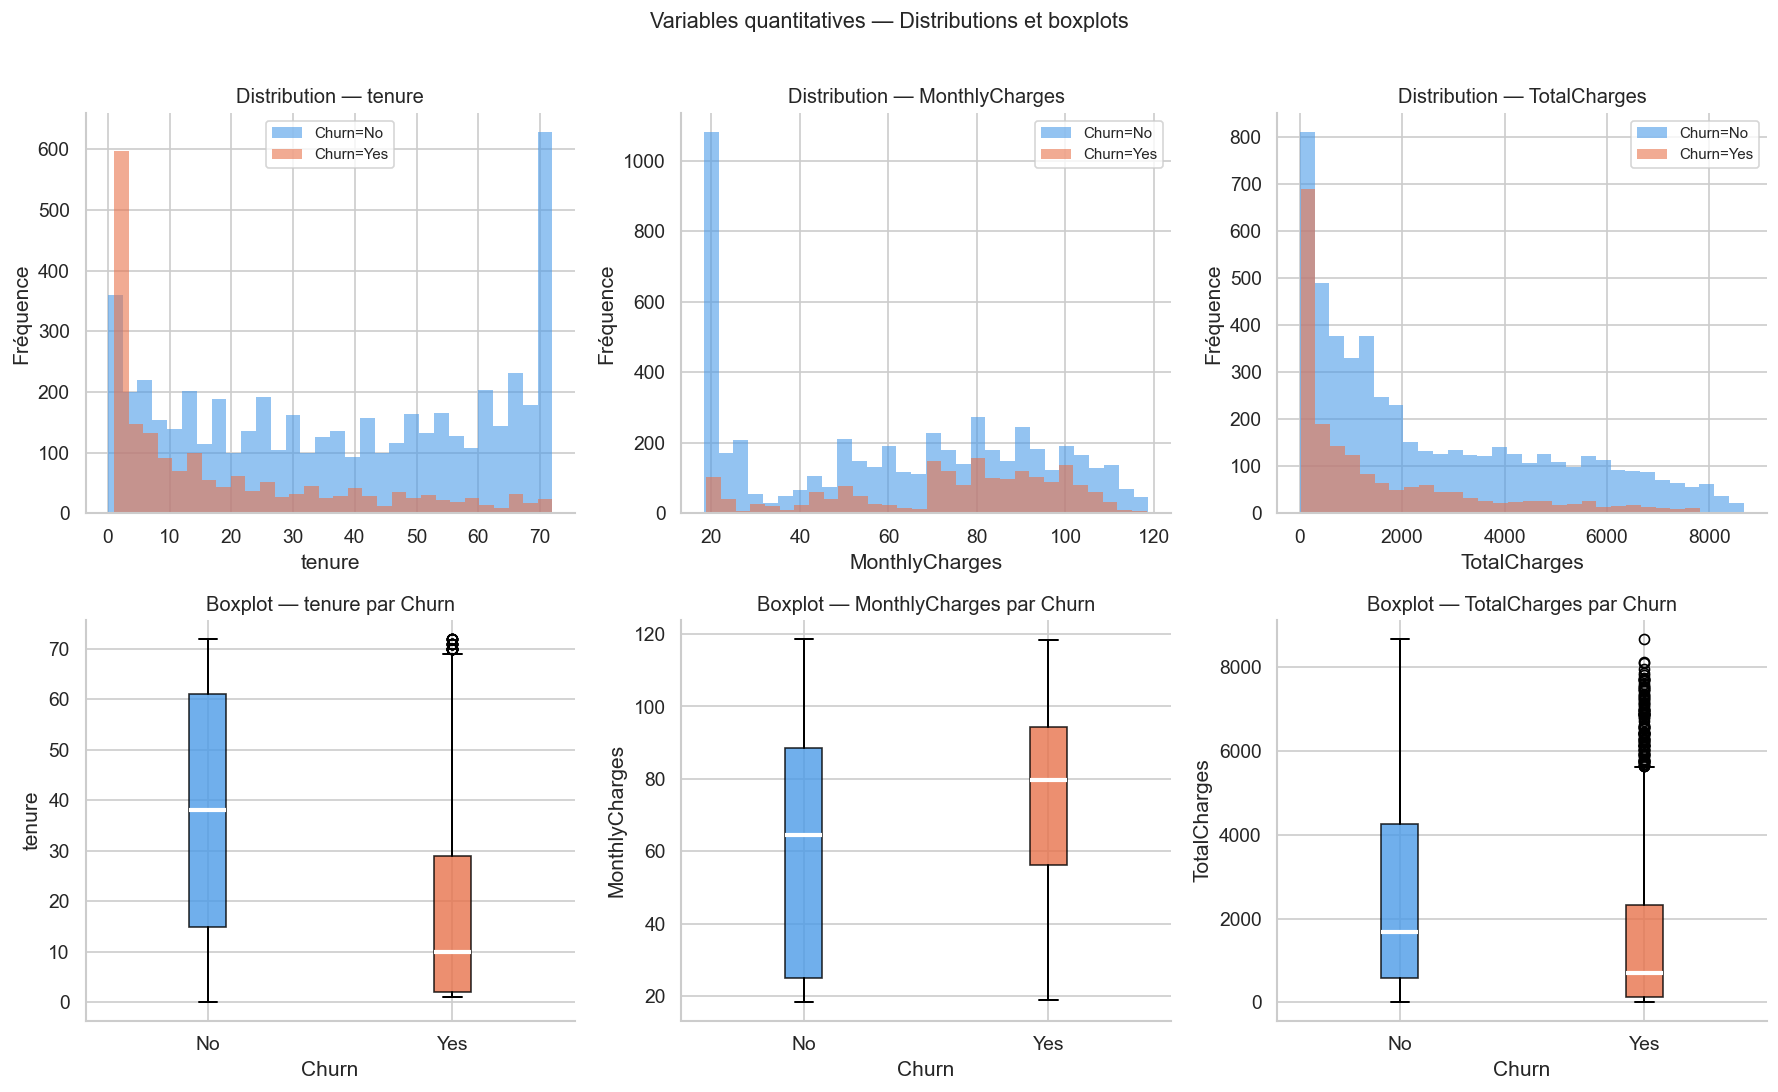

✅ fig2 sauvegardée


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(num_cols):
    # Histogrammes
    for churn_val, color in PALETTE.items():
        subset = df[df['Churn'] == churn_val][col]
        axes[0, i].hist(subset, bins=30, alpha=0.6, color=color,
                        label=f'Churn={churn_val}', edgecolor='none')
    axes[0, i].set_title(f'Distribution — {col}', fontsize=12)
    axes[0, i].set_xlabel(col); axes[0, i].set_ylabel('Fréquence')
    axes[0, i].legend(fontsize=9)

    # Boxplots
    data_by_churn = [df[df['Churn'] == v][col].dropna().values for v in ['No', 'Yes']]
    bp = axes[1, i].boxplot(data_by_churn, patch_artist=True,
                             medianprops=dict(color='white', linewidth=2.5),
                             whiskerprops=dict(linewidth=1.2),
                             capprops=dict(linewidth=1.2))
    for patch, color in zip(bp['boxes'], [BLUE, ORANGE]):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    axes[1, i].set_xticks([1, 2]); axes[1, i].set_xticklabels(['No', 'Yes'])
    axes[1, i].set_title(f'Boxplot — {col} par Churn', fontsize=12)
    axes[1, i].set_xlabel('Churn'); axes[1, i].set_ylabel(col)

plt.suptitle('Variables quantitatives — Distributions et boxplots', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig2_quantitative.png', bbox_inches='tight')
plt.show()
print('✅ fig2 sauvegardée')

## 5. Variables qualitatives — Impact sur le Churn

### 5.1 Variables contractuelles

In [9]:
print('Taux de Churn par Contract :')
print(df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(1))
print('\nTaux de Churn par InternetService :')
print(df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(1))
print('\nTaux de Churn par PaymentMethod :')
print(df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(1))

Taux de Churn par Contract :
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

Taux de Churn par InternetService :
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

Taux de Churn par PaymentMethod :
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64


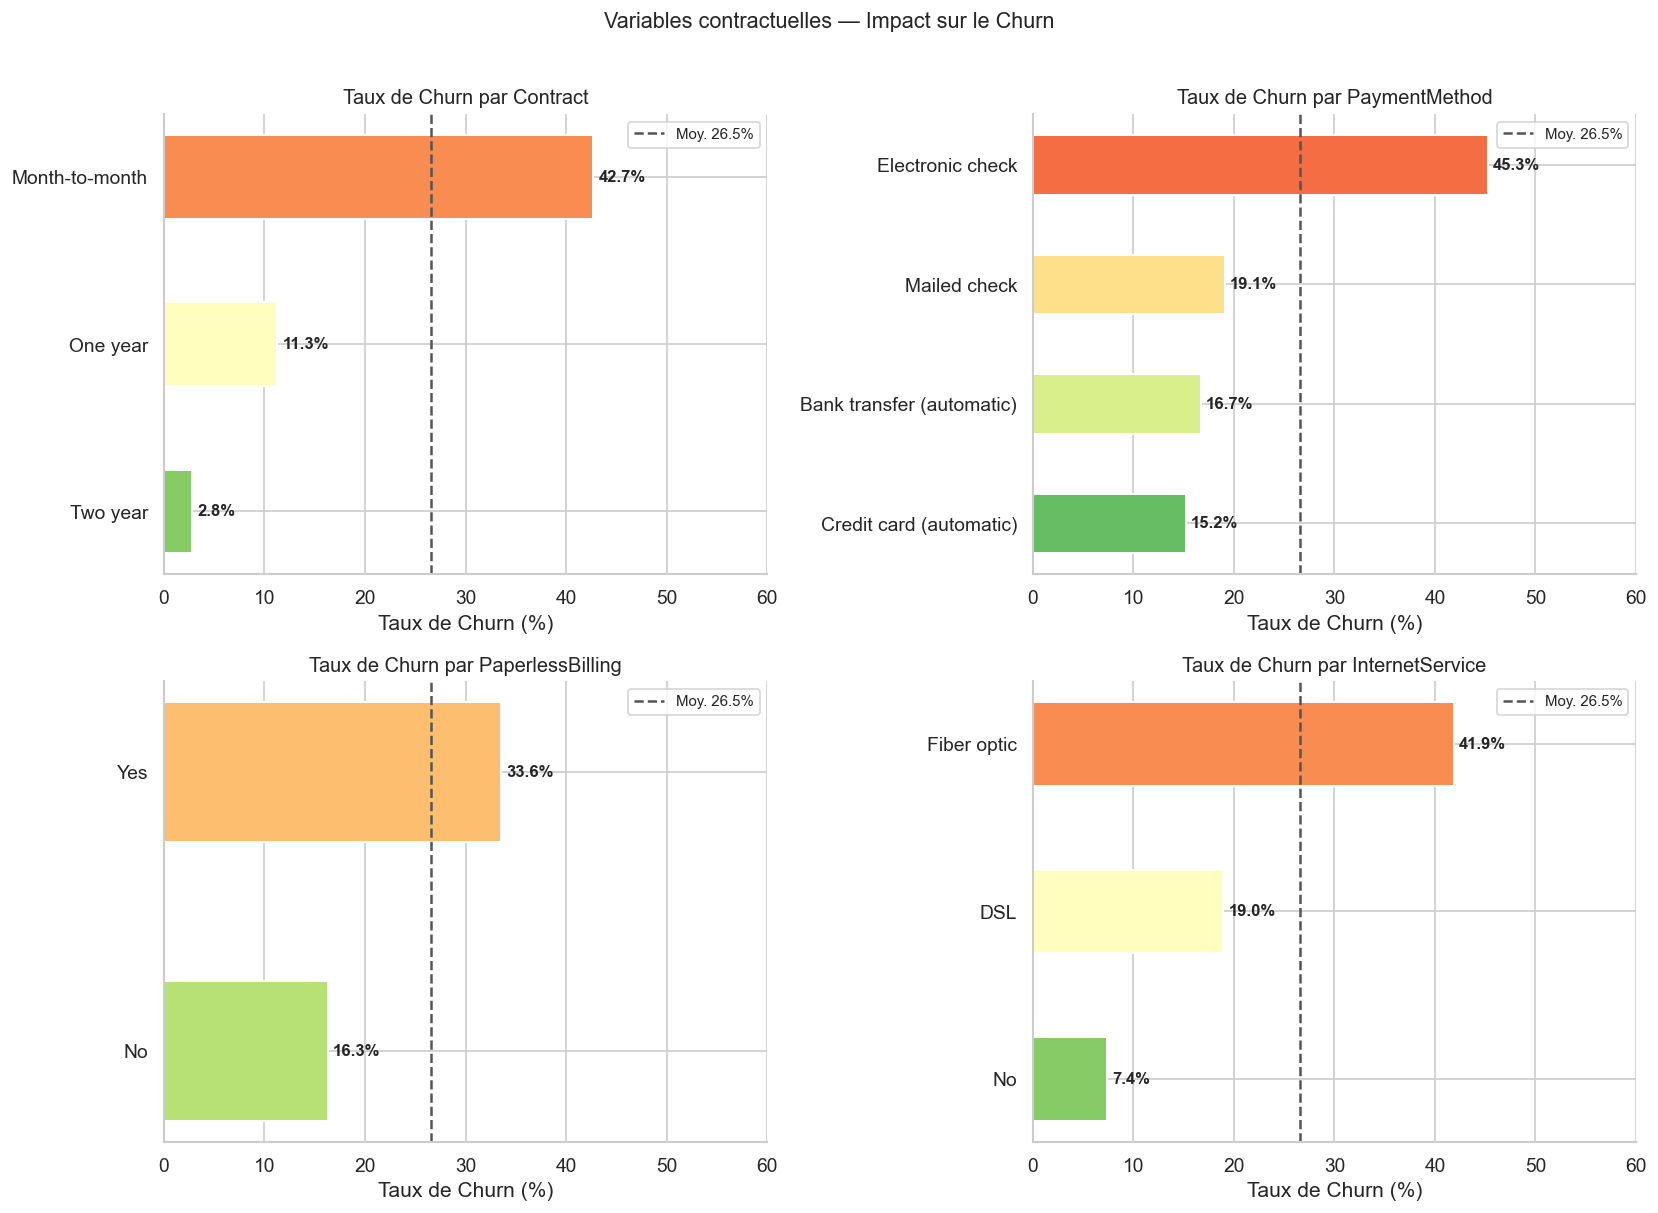

✅ fig3 sauvegardée


In [10]:
contract_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling', 'InternetService']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, contract_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean() * 100).sort_values(ascending=True)
    colors_bar = sns.color_palette('RdYlGn_r', len(churn_rate))
    bars = ax.barh(churn_rate.index, churn_rate.values,
                   color=colors_bar, edgecolor='white', linewidth=1.2, height=0.5)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
    ax.axvline(x=churn_pct['Yes'], color='#555', linestyle='--', linewidth=1.5,
               label=f'Moy. {churn_pct["Yes"]:.1f}%')
    ax.set_title(f'Taux de Churn par {col}', fontsize=12)
    ax.set_xlim(0, 60); ax.set_xlabel('Taux de Churn (%)')
    ax.legend(fontsize=9)

plt.suptitle('Variables contractuelles — Impact sur le Churn', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig3_contract_impact.png', bbox_inches='tight')
plt.show()
print('✅ fig3 sauvegardée')

### 5.2 Variables démographiques

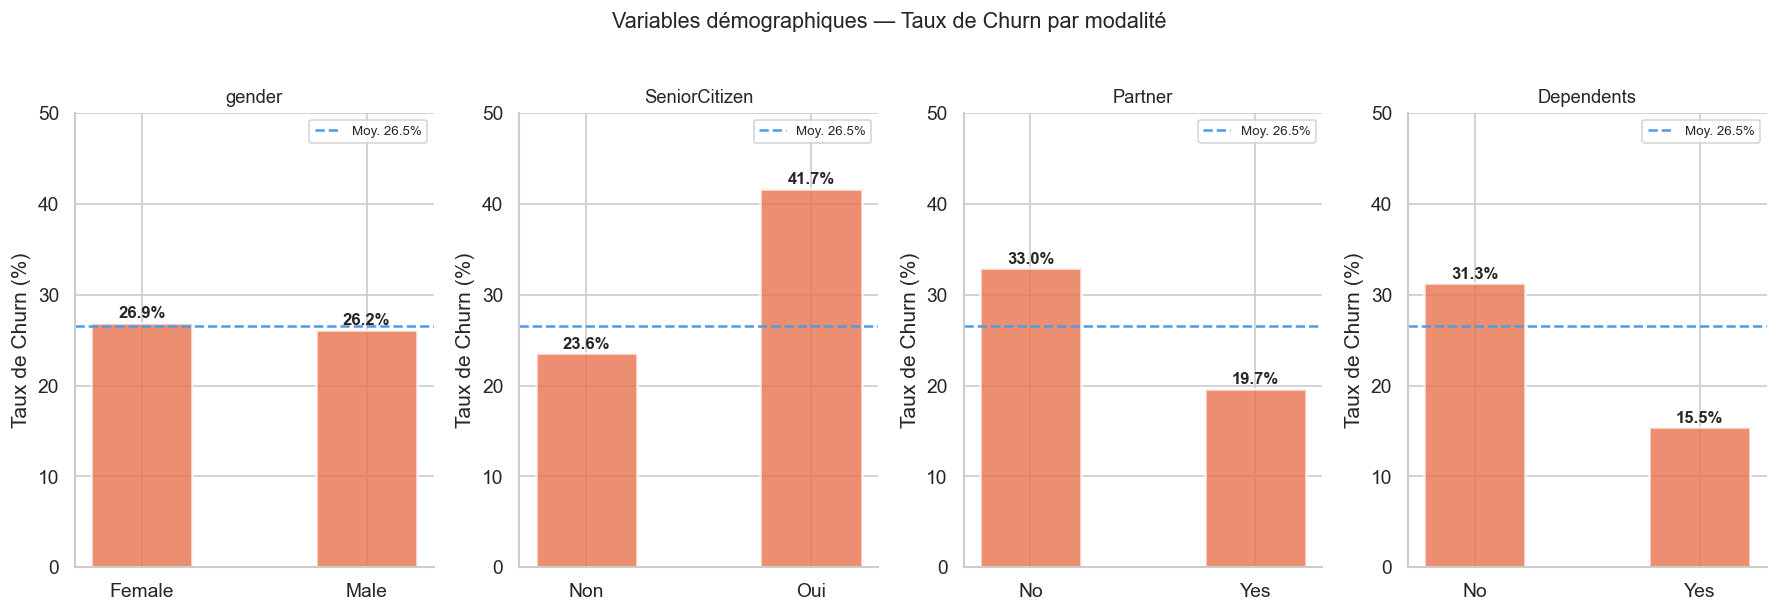

✅ fig5 sauvegardée


In [11]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, col in zip(axes, demo_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=ORANGE, alpha=0.8, edgecolor='white', linewidth=1.5, width=0.45)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(y=churn_pct['Yes'], color=BLUE, linestyle='--',
               linewidth=1.5, label=f'Moy. {churn_pct["Yes"]:.1f}%')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_ylim(0, 50); ax.set_ylabel('Taux de Churn (%)')
    ax.legend(fontsize=8)

plt.suptitle('Variables démographiques — Taux de Churn par modalité', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/fig5_demographic.png', bbox_inches='tight')
plt.show()
print('✅ fig5 sauvegardée')

## 6. Matrice de corrélation

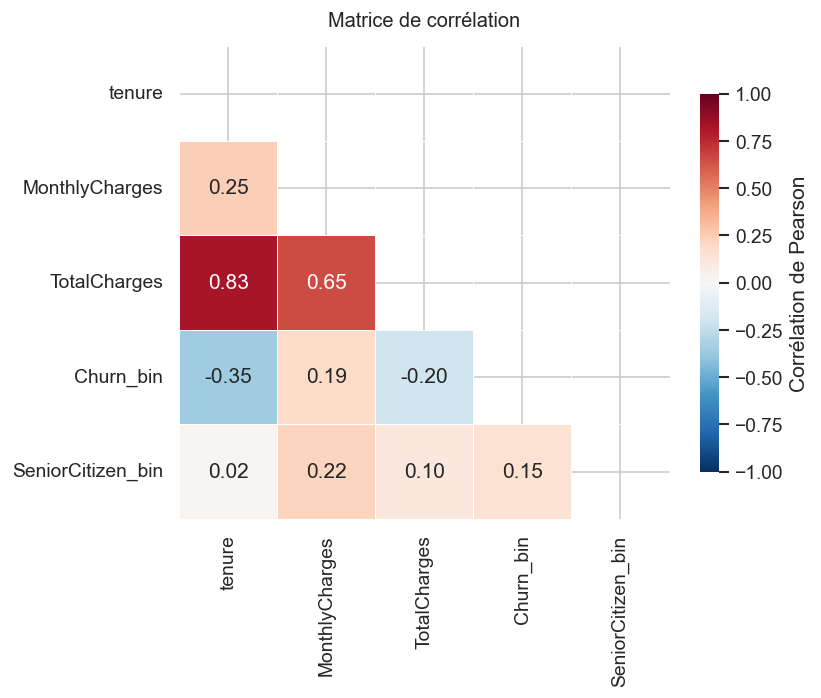

✅ fig4 sauvegardée

Corrélations avec Churn :
tenure              -0.352
TotalCharges        -0.198
MonthlyCharges       0.193
SeniorCitizen_bin    0.151
Name: Churn_bin, dtype: float64


In [12]:
df_corr = df[['tenure','MonthlyCharges','TotalCharges']].copy()
df_corr['Churn_bin'] = (df['Churn']=='Yes').astype(int)
df_corr['SeniorCitizen_bin'] = (df['SeniorCitizen']=='Oui').astype(int)

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'})
ax.set_title('Matrice de corrélation', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../reports/fig4_correlation.png', bbox_inches='tight')
plt.show()
print('✅ fig4 sauvegardée')

print('\nCorrélations avec Churn :')
print(corr['Churn_bin'].drop('Churn_bin').sort_values(key=abs, ascending=False).round(3))

## 7. Séparation des variables

In [13]:
quantitative_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

qualitative_vars = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

print(f'Variables QUANTITATIVES ({len(quantitative_vars)}) : {quantitative_vars}')
print(f'\nVariables QUALITATIVES ({len(qualitative_vars)}) :')
for v in qualitative_vars:
    print(f'  - {v:22s} | {df[v].nunique()} modalités : {df[v].unique().tolist()}')

Variables QUANTITATIVES (3) : ['tenure', 'MonthlyCharges', 'TotalCharges']

Variables QUALITATIVES (16) :
  - gender                 | 2 modalités : ['Female', 'Male']
  - SeniorCitizen          | 2 modalités : ['Non', 'Oui']
  - Partner                | 2 modalités : ['Yes', 'No']
  - Dependents             | 2 modalités : ['No', 'Yes']
  - PhoneService           | 2 modalités : ['No', 'Yes']
  - MultipleLines          | 3 modalités : ['No phone service', 'No', 'Yes']
  - InternetService        | 3 modalités : ['DSL', 'Fiber optic', 'No']
  - OnlineSecurity         | 3 modalités : ['No', 'Yes', 'No internet service']
  - OnlineBackup           | 3 modalités : ['Yes', 'No', 'No internet service']
  - DeviceProtection       | 3 modalités : ['No', 'Yes', 'No internet service']
  - TechSupport            | 3 modalités : ['No', 'Yes', 'No internet service']
  - StreamingTV            | 3 modalités : ['No', 'Yes', 'No internet service']
  - StreamingMovies        | 3 modalités : ['No', 'Yes

## 8. Sauvegarde

In [14]:
df.to_csv('../data/processed/churn_cleaned.csv', index=False)

meta = {
    'quantitative': quantitative_vars,
    'qualitative': qualitative_vars,
    'target': 'Churn',
    'id_col': 'customerID',
    'churn_rate_pct': round((df['Churn']=='Yes').mean()*100, 2),
    'n_samples': len(df),
    'n_churn_yes': int((df['Churn']=='Yes').sum()),
    'n_churn_no': int((df['Churn']=='No').sum())
}
with open('../data/processed/variables_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ data/processed/churn_cleaned.csv sauvegardé')
print('✅ data/processed/variables_meta.json sauvegardé')
print('\nEDA terminée ! Prochaine étape → 02_statistical_tests.ipynb')

✅ data/processed/churn_cleaned.csv sauvegardé
✅ data/processed/variables_meta.json sauvegardé

EDA terminée ! Prochaine étape → 02_statistical_tests.ipynb


## 9. 📋 Synthèse EDA

| # | Observation | Impact |
|---|---|---|
| 1 | 7 043 clients, 21 variables mixtes | Dataset raisonnable |
| 2 | Déséquilibre 73.5% / 26.5% (ratio 2.77:1) | → SMOTE-NC étape 4 |
| 3 | 11 valeurs `TotalCharges` vides → imputées | Dataset propre ✓ |
| 4 | `tenure` : médiane 38 (No) vs 10 mois (Yes) | Très discriminante |
| 5 | `MonthlyCharges` : churners paient ~24% plus | Significative |
| 6 | `Contract` Month-to-month → 42.7% churn | La plus impactante |
| 7 | `Fiber optic` → 41.9% vs 7.4% | Service à risque |
| 8 | Variables démographiques (genre) = faible impact | Peut être exclue |

**→ Prochaine étape : `02_statistical_tests.ipynb` — Tests ANOVA + χ²**